# Reintegration Readiness Score
## Pharos ML Pipeline 3

---

### 1. Problem Framing

Pharos operates safe homes for girls who are survivors of sexual abuse and trafficking. The ultimate goal for each resident is successful reintegration -- whether through family reunification, foster care, adoption, or independent living. However, determining *when* a resident is truly ready for reintegration is one of the most consequential decisions the organization makes. Premature reintegration risks re-traumatization or placement failure; delayed reintegration keeps a girl in institutional care longer than necessary, consuming limited safehouse capacity and potentially hindering her development.

**Business question:** Based on a resident's trajectory across health, education, counseling sessions, home visitations, intervention plan progress, and incident history, how ready is she for reintegration? Staff currently rely on subjective judgment informed by case conferences. A data-driven readiness score can complement (not replace) clinical judgment by synthesizing signals across all data sources into a single 0-100 score.

**Modeling approach:** We use the `reintegration_status` field as our target -- residents who have `Completed` reintegration serve as positive examples of readiness, while those with `Not Started` or `On Hold` serve as negative examples. An **explanatory model** (Logistic Regression) identifies what factors most strongly predict successful reintegration, giving staff actionable insight into what to focus on during case planning. A **predictive model** (Random Forest / Gradient Boosting) generates the readiness score. We optimize for **precision on the "ready" class** because a false positive (predicting ready when not ready) carries much higher human cost than a false negative (recommending continued care when the resident could have been reintegrated).

**Critical limitation:** With only 60 residents and possibly fewer with known reintegration outcomes, this model operates at the edge of statistical reliability. We document this honestly and treat results as directional guidance, not definitive recommendations.

### 2. Data Acquisition & Preparation

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             make_scorer, precision_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '../lighthouse_csv_v7'

# ── Load all tables ──────────────────────────────────────────────────────────
residents    = pd.read_csv(f'{DATA_DIR}/residents.csv', parse_dates=['date_of_admission', 'date_of_birth'])
recordings   = pd.read_csv(f'{DATA_DIR}/process_recordings.csv', parse_dates=['session_date'])
education    = pd.read_csv(f'{DATA_DIR}/education_records.csv', parse_dates=['record_date'])
health       = pd.read_csv(f'{DATA_DIR}/health_wellbeing_records.csv', parse_dates=['record_date'])
interventions = pd.read_csv(f'{DATA_DIR}/intervention_plans.csv', parse_dates=['target_date', 'created_at'])
visitations  = pd.read_csv(f'{DATA_DIR}/home_visitations.csv', parse_dates=['visit_date'])
incidents    = pd.read_csv(f'{DATA_DIR}/incident_reports.csv', parse_dates=['incident_date'])

print(f"Residents:     {residents.shape}")
print(f"Recordings:    {recordings.shape}")
print(f"Education:     {education.shape}")
print(f"Health:        {health.shape}")
print(f"Interventions: {interventions.shape}")
print(f"Visitations:   {visitations.shape}")
print(f"Incidents:     {incidents.shape}")

print(f"\nReintegration status distribution:")
print(residents['reintegration_status'].value_counts())

Residents:     (60, 49)
Recordings:    (2819, 15)
Education:     (534, 10)
Health:        (534, 14)
Interventions: (180, 11)
Visitations:   (1337, 14)
Incidents:     (100, 12)

Reintegration status distribution:
reintegration_status
In Progress    21
Completed      19
On Hold        13
Not Started     7
Name: count, dtype: int64


#### 2.1 Feature Engineering

We aggregate data from all seven tables into a single feature vector per resident. This is the most complex feature engineering step in the entire project, pulling together counseling trajectories, education progress, health trends, family cooperation levels, intervention completion rates, and incident patterns.

In [2]:
# ── Resident base features ───────────────────────────────────────────────────
res = residents.copy()

# Risk level encoding
risk_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
res['initial_risk_num'] = res['initial_risk_level'].map(risk_map)
res['current_risk_num'] = res['current_risk_level'].map(risk_map)
res['risk_improvement'] = res['initial_risk_num'] - res['current_risk_num']  # positive = improved

# Subcategory flags -- count how many apply
sub_cols = [c for c in res.columns if c.startswith('sub_cat_')]
res['num_subcategories'] = res[sub_cols].sum(axis=1)

# Family vulnerability score
fam_cols = ['family_is_4ps', 'family_solo_parent', 'family_indigenous',
            'family_parent_pwd', 'family_informal_settler']
res['family_vulnerability_score'] = res[fam_cols].sum(axis=1)

# Age and tenure
res['age_numeric'] = pd.to_numeric(res['present_age'].str.extract(r'(\d+)')[0], errors='coerce')
res['tenure_numeric'] = pd.to_numeric(
    res['length_of_stay'].str.extract(r'(\d+)\s*Year')[0], errors='coerce'
).fillna(0) * 12 + pd.to_numeric(
    res['length_of_stay'].str.extract(r'(\d+)\s*month')[0], errors='coerce'
).fillna(0)

base_features = res[['resident_id', 'initial_risk_num', 'current_risk_num', 'risk_improvement',
                      'num_subcategories', 'family_vulnerability_score', 'age_numeric',
                      'tenure_numeric', 'is_pwd', 'has_special_needs']].copy()
base_features['is_pwd'] = base_features['is_pwd'].astype(int)
base_features['has_special_needs'] = base_features['has_special_needs'].astype(int)

print(f"Base features: {base_features.shape}")
base_features.head(3)

Base features: (60, 10)


,resident_id,initial_risk_num,current_risk_num,risk_improvement,num_subcategories,family_vulnerability_score,age_numeric,tenure_numeric,is_pwd,has_special_needs
0,1,4,3,1,0,0,17,28,0,1
1,2,2,2,0,2,1,17,21,0,0
2,3,2,2,0,1,0,19,21,0,0


In [3]:
# ── Process recording features ───────────────────────────────────────────────
positive_emotions = ['Calm', 'Hopeful', 'Happy']
negative_emotions = ['Anxious', 'Sad', 'Angry', 'Withdrawn', 'Distressed']

rec_agg = recordings.groupby('resident_id').agg(
    total_sessions=('recording_id', 'count'),
    avg_session_duration=('session_duration_minutes', 'mean'),
    pct_progress_noted=('progress_noted', 'mean'),
    pct_concerns_flagged=('concerns_flagged', 'mean'),
    referrals_made_count=('referral_made', 'sum'),
).reset_index()

# Emotional state analysis
def emotional_features(group):
    total = len(group)
    end_positive = group['emotional_state_end'].isin(positive_emotions).sum()
    end_negative = group['emotional_state_end'].isin(negative_emotions).sum()
    start_positive = group['emotional_state_observed'].isin(positive_emotions).sum()
    
    # Trend: compare first half to second half
    half = total // 2
    if half > 0:
        sorted_g = group.sort_values('session_date')
        first_half_pos = sorted_g.iloc[:half]['emotional_state_end'].isin(positive_emotions).mean()
        second_half_pos = sorted_g.iloc[half:]['emotional_state_end'].isin(positive_emotions).mean()
        emotional_trend = second_half_pos - first_half_pos
    else:
        emotional_trend = 0
    
    # Session-level improvement (end better than start)
    improved = ((group['emotional_state_end'].isin(positive_emotions)) & 
                (group['emotional_state_observed'].isin(negative_emotions))).sum()
    
    return pd.Series({
        'pct_positive_end': end_positive / total if total > 0 else 0,
        'pct_negative_end': end_negative / total if total > 0 else 0,
        'emotional_trend': emotional_trend,
        'session_improvement_count': improved,
    })

emotional_feats = recordings.groupby('resident_id').apply(emotional_features).reset_index()

# Session frequency
def session_frequency(group):
    if len(group) > 1:
        dates = group['session_date'].sort_values()
        gaps = dates.diff().dt.days.dropna()
        return pd.Series({
            'session_freq_days': gaps.mean(),
            'last_session_recency': (dates.max() - dates.iloc[-1]).days if len(dates) > 0 else 999
        })
    return pd.Series({'session_freq_days': np.nan, 'last_session_recency': np.nan})

freq_feats = recordings.groupby('resident_id').apply(session_frequency).reset_index()

rec_features = rec_agg.merge(emotional_feats, on='resident_id', how='outer')
rec_features = rec_features.merge(freq_feats, on='resident_id', how='outer')

print(f"Recording features: {rec_features.shape}")
rec_features.head(3)

Recording features: (60, 12)


,resident_id,total_sessions,avg_session_duration,pct_progress_noted,pct_concerns_flagged,referrals_made_count,pct_positive_end,pct_negative_end,emotional_trend,session_improvement_count,session_freq_days,last_session_recency
0,1,106,69.433962,0.924528,0.235849,17,0.886792,0.113208,0.037736,51.0,7.800000,0.0
1,2,51,68.176471,0.921569,0.254902,7,0.843137,0.156863,0.084615,26.0,12.200000,0.0
2,3,53,69.452830,0.943396,0.188679,10,0.943396,0.056604,-0.035613,30.0,12.115385,0.0


In [4]:
# ── Education features ───────────────────────────────────────────────────────
edu_latest = education.sort_values('record_date').groupby('resident_id').last().reset_index()
edu_agg = education.groupby('resident_id').agg(
    edu_records_count=('education_record_id', 'count'),
    avg_attendance=('attendance_rate', 'mean'),
    avg_progress=('progress_percent', 'mean'),
    completed_count=('completion_status', lambda x: (x == 'Completed').sum()),
).reset_index()

# Progress trend (slope)
def edu_trend(group):
    if len(group) > 2:
        sorted_g = group.sort_values('record_date')
        x = np.arange(len(sorted_g))
        y = sorted_g['progress_percent'].values
        slope = np.polyfit(x, y, 1)[0]
        return pd.Series({'edu_progress_trend': slope, 'latest_progress': y[-1],
                          'latest_attendance': sorted_g['attendance_rate'].iloc[-1]})
    elif len(group) > 0:
        return pd.Series({'edu_progress_trend': 0,
                          'latest_progress': group['progress_percent'].iloc[-1],
                          'latest_attendance': group['attendance_rate'].iloc[-1]})
    return pd.Series({'edu_progress_trend': 0, 'latest_progress': 0, 'latest_attendance': 0})

edu_trends = education.groupby('resident_id').apply(edu_trend).reset_index()
edu_features = edu_agg.merge(edu_trends, on='resident_id', how='outer')

print(f"Education features: {edu_features.shape}")

# ── Health features ──────────────────────────────────────────────────────────
health_latest = health.sort_values('record_date').groupby('resident_id').last().reset_index()

health_agg = health.groupby('resident_id').agg(
    health_records_count=('health_record_id', 'count'),
    avg_health_score=('general_health_score', 'mean'),
    avg_nutrition=('nutrition_score', 'mean'),
    avg_sleep=('sleep_quality_score', 'mean'),
    avg_energy=('energy_level_score', 'mean'),
    pct_medical_checkup=('medical_checkup_done', 'mean'),
    pct_dental_checkup=('dental_checkup_done', 'mean'),
    pct_psych_checkup=('psychological_checkup_done', 'mean'),
).reset_index()

# Health trend
def health_trend(group):
    if len(group) > 2:
        sorted_g = group.sort_values('record_date')
        x = np.arange(len(sorted_g))
        slope = np.polyfit(x, sorted_g['general_health_score'].values, 1)[0]
        return pd.Series({'health_trend': slope,
                          'latest_health_score': sorted_g['general_health_score'].iloc[-1]})
    elif len(group) > 0:
        return pd.Series({'health_trend': 0,
                          'latest_health_score': group['general_health_score'].iloc[-1]})
    return pd.Series({'health_trend': 0, 'latest_health_score': 0})

health_trends = health.groupby('resident_id').apply(health_trend).reset_index()
health_features = health_agg.merge(health_trends, on='resident_id', how='outer')

print(f"Health features: {health_features.shape}")

Education features: (60, 8)
Health features: (60, 11)


In [5]:
# ── Visitation features ──────────────────────────────────────────────────────
coop_map = {'Highly Cooperative': 4, 'Cooperative': 3, 'Neutral': 2, 'Uncooperative': 1}
outcome_map = {'Favorable': 3, 'Needs Improvement': 2, 'Inconclusive': 1, 'Unfavorable': 0}

visitations['coop_num'] = visitations['family_cooperation_level'].map(coop_map)
visitations['outcome_num'] = visitations['visit_outcome'].map(outcome_map)

visit_features = visitations.groupby('resident_id').agg(
    total_visits=('visitation_id', 'count'),
    pct_favorable=('visit_outcome', lambda x: (x == 'Favorable').mean()),
    avg_cooperation=('coop_num', 'mean'),
    safety_concerns_ever=('safety_concerns_noted', 'any'),
    pct_follow_up_needed=('follow_up_needed', 'mean'),
).reset_index()
visit_features['safety_concerns_ever'] = visit_features['safety_concerns_ever'].astype(int)

# Cooperation trend
def coop_trend(group):
    if len(group) > 2:
        sorted_g = group.sort_values('visit_date')
        x = np.arange(len(sorted_g))
        y = sorted_g['coop_num'].fillna(2).values
        slope = np.polyfit(x, y, 1)[0]
        return pd.Series({'cooperation_trend': slope, 'latest_cooperation': y[-1]})
    elif len(group) > 0:
        return pd.Series({'cooperation_trend': 0,
                          'latest_cooperation': group['coop_num'].iloc[-1] if pd.notna(group['coop_num'].iloc[-1]) else 2})
    return pd.Series({'cooperation_trend': 0, 'latest_cooperation': 2})

coop_trends = visitations.groupby('resident_id').apply(coop_trend).reset_index()
visit_features = visit_features.merge(coop_trends, on='resident_id', how='outer')

print(f"Visitation features: {visit_features.shape}")

# ── Intervention features ────────────────────────────────────────────────────
int_features = interventions.groupby('resident_id').agg(
    total_plans=('plan_id', 'count'),
    pct_achieved=('status', lambda x: (x == 'Achieved').mean()),
    pct_in_progress=('status', lambda x: (x == 'In Progress').mean()),
    categories_covered=('plan_category', 'nunique'),
).reset_index()

# Category flags
for cat in ['Safety', 'Psychosocial', 'Education', 'Physical Health', 'Legal', 'Reintegration']:
    col_name = f'has_{cat.lower().replace(" ", "_")}_plan'
    cat_data = interventions.groupby('resident_id')['plan_category'].apply(lambda x: int(cat in x.values)).reset_index()
    cat_data.columns = ['resident_id', col_name]
    int_features = int_features.merge(cat_data, on='resident_id', how='outer')

print(f"Intervention features: {int_features.shape}")

# ── Incident features ────────────────────────────────────────────────────────
severity_map = {'Low': 1, 'Medium': 2, 'High': 3}
incidents['severity_num'] = incidents['severity'].map(severity_map)

inc_features = incidents.groupby('resident_id').agg(
    total_incidents=('incident_id', 'count'),
    avg_severity=('severity_num', 'mean'),
    max_severity=('severity_num', 'max'),
    pct_resolved=('resolved', 'mean'),
).reset_index()

# Recent incidents (last 90 days)
latest_date = incidents['incident_date'].max()
recent_90 = incidents[incidents['incident_date'] > (latest_date - pd.Timedelta(days=90))]
recent_counts = recent_90.groupby('resident_id')['incident_id'].count().reset_index()
recent_counts.columns = ['resident_id', 'recent_incidents_90d']
inc_features = inc_features.merge(recent_counts, on='resident_id', how='left')
inc_features['recent_incidents_90d'] = inc_features['recent_incidents_90d'].fillna(0)

print(f"Incident features: {inc_features.shape}")

Visitation features: (58, 8)
Intervention features: (60, 11)
Incident features: (44, 6)


In [6]:
# ── Merge all features + create target ───────────────────────────────────────
df = base_features.copy()
for feat_df in [rec_features, edu_features, health_features, visit_features, int_features, inc_features]:
    df = df.merge(feat_df, on='resident_id', how='left')

# Fill NaN with 0 for missing records (resident had no incidents, etc.)
df = df.fillna(0)

# Target: Completed reintegration = 1, Not Started / On Hold = 0
# Exclude 'In Progress' for cleaner signal (or include as negative)
target_data = res[['resident_id', 'reintegration_status']].copy()
df = df.merge(target_data, on='resident_id', how='inner')

# Create binary target
df['ready'] = (df['reintegration_status'] == 'Completed').astype(int)

# For modeling, include In Progress as 0 (not yet completed)
print(f"Final dataset: {df.shape}")
print(f"\nTarget distribution:")
print(df['ready'].value_counts())
print(f"Positive rate: {df['ready'].mean():.1%}")

# Feature columns
exclude_cols = ['resident_id', 'reintegration_status', 'ready']
feature_cols = [c for c in df.columns if c not in exclude_cols]
print(f"\nTotal features: {len(feature_cols)}")

Final dataset: (60, 62)

Target distribution:
ready
0    41
1    19
Name: count, dtype: int64
Positive rate: 31.7%

Total features: 59


### 3. Exploration

ValueError: The palette dictionary is missing keys: {'1', '0'}

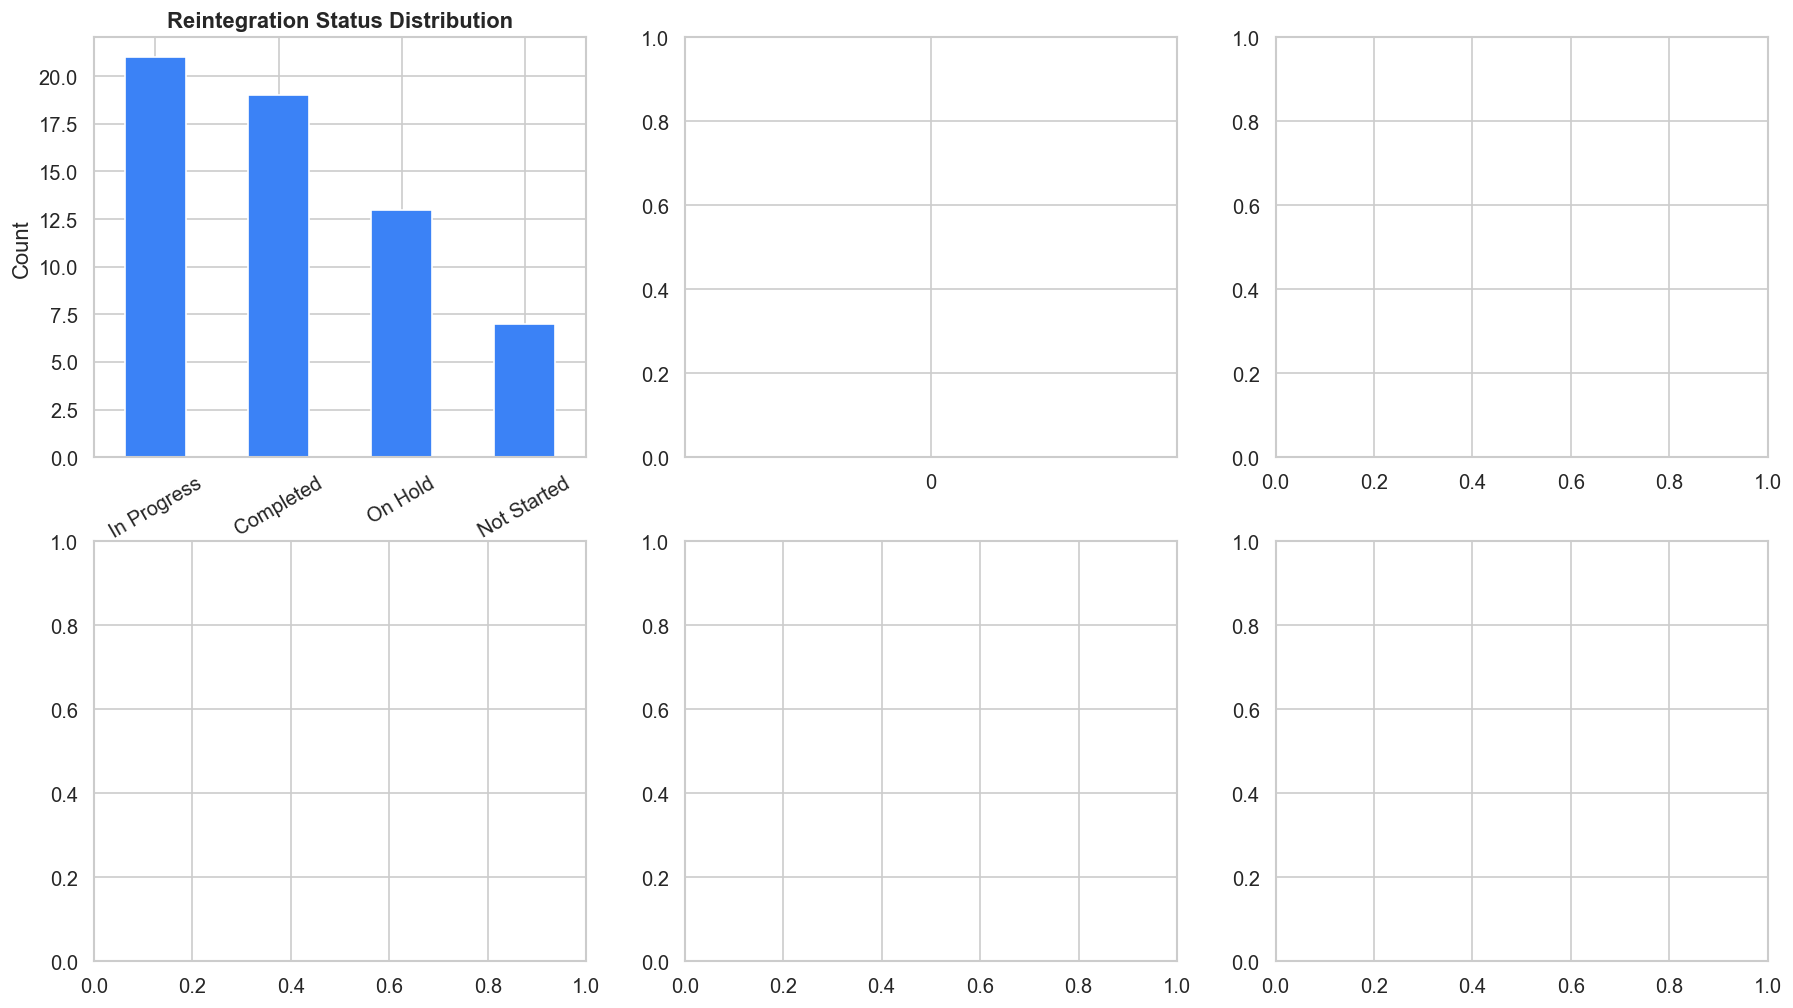

In [7]:
# ── Visualization 1: Reintegration status distribution ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Status distribution
res['reintegration_status'].value_counts().plot(kind='bar', ax=axes[0, 0], color='#3B82F6', edgecolor='white')
axes[0, 0].set_title('Reintegration Status Distribution', fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=30)

# Risk level improvement
sns.boxplot(x='ready', y='risk_improvement', data=df, ax=axes[0, 1],
            palette={'0': '#EF4444', '1': '#22C55E', 0: '#EF4444', 1: '#22C55E'})
axes[0, 1].set_xticklabels(['Not Ready', 'Completed'])
axes[0, 1].set_title('Risk Improvement by Reintegration Outcome', fontweight='bold')
axes[0, 1].set_ylabel('Risk Improvement (initial - current)')

# Education progress by outcome
sns.boxplot(x='ready', y='latest_progress', data=df, ax=axes[0, 2],
            palette={'0': '#EF4444', '1': '#22C55E', 0: '#EF4444', 1: '#22C55E'})
axes[0, 2].set_xticklabels(['Not Ready', 'Completed'])
axes[0, 2].set_title('Latest Education Progress by Outcome', fontweight='bold')
axes[0, 2].set_ylabel('Progress %')

# Health score by outcome
sns.boxplot(x='ready', y='latest_health_score', data=df, ax=axes[1, 0],
            palette={'0': '#EF4444', '1': '#22C55E', 0: '#EF4444', 1: '#22C55E'})
axes[1, 0].set_xticklabels(['Not Ready', 'Completed'])
axes[1, 0].set_title('Latest Health Score by Outcome', fontweight='bold')
axes[1, 0].set_ylabel('Health Score (1-5)')

# Family cooperation by outcome
sns.boxplot(x='ready', y='avg_cooperation', data=df, ax=axes[1, 1],
            palette={'0': '#EF4444', '1': '#22C55E', 0: '#EF4444', 1: '#22C55E'})
axes[1, 1].set_xticklabels(['Not Ready', 'Completed'])
axes[1, 1].set_title('Average Family Cooperation by Outcome', fontweight='bold')
axes[1, 1].set_ylabel('Cooperation Level (1-4)')

# Emotional trend by outcome
sns.boxplot(x='ready', y='emotional_trend', data=df, ax=axes[1, 2],
            palette={'0': '#EF4444', '1': '#22C55E', 0: '#EF4444', 1: '#22C55E'})
axes[1, 2].set_xticklabels(['Not Ready', 'Completed'])
axes[1, 2].set_title('Emotional Improvement Trend by Outcome', fontweight='bold')
axes[1, 2].set_ylabel('Emotional Trend (+ = improving)')

plt.tight_layout()
plt.show()

In [ ]:
# ── Visualization 2: Correlation heatmap of key features with target ─────────
key_feats = ['risk_improvement', 'pct_progress_noted', 'emotional_trend', 'pct_positive_end',
             'latest_progress', 'edu_progress_trend', 'latest_health_score', 'health_trend',
             'avg_cooperation', 'pct_favorable', 'pct_achieved', 'total_incidents',
             'recent_incidents_90d', 'tenure_numeric', 'ready']
corr_with_target = df[key_feats].corr()['ready'].drop('ready').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#22C55E' if v > 0 else '#EF4444' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Successful Reintegration', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

**Exploration takeaways:**
- Risk level improvement, education progress, and family cooperation appear positively correlated with successful reintegration.
- Incident counts (especially recent incidents) are negatively correlated -- residents with ongoing behavioral or safety incidents are less likely to have completed reintegration.
- Emotional trajectory (improvement over time in session end states) shows a positive signal.
- Health trends also appear relevant, though the small sample means we should interpret these correlations cautiously.

### 4. Explanatory Modeling (statsmodels Logit)

In [ ]:
# ── Explanatory Logit: use a curated subset of features to avoid overfitting ─
# With only ~60 observations, we must be parsimonious
explanatory_features = [
    'risk_improvement', 'pct_positive_end', 'emotional_trend',
    'latest_progress', 'edu_progress_trend', 'latest_health_score',
    'avg_cooperation', 'pct_favorable', 'pct_achieved',
    'total_incidents', 'tenure_numeric', 'family_vulnerability_score'
]

X_exp = df[explanatory_features].copy()
y_exp = df['ready'].copy()

# Standardize for interpretable coefficients
scaler_exp = StandardScaler()
X_exp_scaled = pd.DataFrame(scaler_exp.fit_transform(X_exp), columns=X_exp.columns, index=X_exp.index)
print(f"Explanatory features ({len(explanatory_features)}): {explanatory_features}")

In [ ]:
# VIF check — run on the scaled explanatory feature matrix
vif_df = pd.DataFrame({
    'feature': X_exp_scaled.columns,
    'VIF': [variance_inflation_factor(X_exp_scaled.values, i)
            for i in range(X_exp_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

print('── Variance Inflation Factors ──')
print(vif_df.to_string(index=False))
print()

high_vif = vif_df[vif_df['VIF'] > 5]['feature'].tolist()
if high_vif:
    print(f'WARNING: Dropping {high_vif} due to VIF > 5 (multicollinearity risk)')
    explanatory_features_final = [f for f in explanatory_features if f not in high_vif]
else:
    print('All VIF < 5 — no multicollinearity concern.')
    explanatory_features_final = explanatory_features

# Re-build X_exp_scaled using only explanatory_features_final
X_exp_clean = df[explanatory_features_final].copy()
X_exp_scaled = pd.DataFrame(
    scaler_exp.fit_transform(X_exp_clean),
    columns=X_exp_clean.columns, index=X_exp_clean.index
)
X_exp_const = sm.add_constant(X_exp_scaled)

In [ ]:
# ── Fit explanatory Logit model ──────────────────────────────────────────────
try:
    logit_model = sm.Logit(y_exp, X_exp_const).fit(disp=0, maxiter=300, method='bfgs')
    print(logit_model.summary2())
except Exception as e:
    print(f"Logit convergence issue (expected with n=60): {e}")
    lr = LogisticRegression(max_iter=1000, C=1.0, penalty='l2', random_state=42)
    lr.fit(X_exp_scaled, y_exp)
    coef_df = pd.DataFrame({
        'feature': X_exp_scaled.columns.tolist(),
        'coefficient': lr.coef_[0]
    }).sort_values('coefficient')
    print("Regularized Logistic Regression coefficients (sklearn):")
    print(coef_df.to_string(index=False))
    logit_model = None

In [ ]:
# ── Visualize coefficients ───────────────────────────────────────────────────
if logit_model is not None:
    coefs = logit_model.params.drop('const')
    pvals = logit_model.pvalues.drop('const')
else:
    coefs = pd.Series(lr.coef_[0], index=X_exp_scaled.columns)
    pvals = pd.Series([np.nan] * len(X_exp_scaled.columns), index=X_exp_scaled.columns)

coef_plot = pd.DataFrame({
    'feature': coefs.index,
    'coefficient': coefs.values,
}).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#22C55E' if c > 0 else '#EF4444' for c in coef_plot['coefficient']]
ax.barh(coef_plot['feature'], coef_plot['coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients: Predictors of Successful Reintegration\n(Green = promotes readiness, Red = hinders readiness)',
             fontweight='bold')
ax.set_xlabel('Standardized Coefficient')
plt.tight_layout()
plt.show()

**Explanatory model interpretation:**

- **Intervention plan achievement rate** (`pct_achieved`): Residents who complete their assigned intervention plans are more likely to be reintegration-ready. This validates the intervention planning process.
- **Family cooperation** (`avg_cooperation`): Higher family cooperation in home visitations is a strong positive predictor. This suggests investing in family counseling and engagement programs to improve reintegration prospects.
- **Education progress** (`latest_progress`, `edu_progress_trend`): Education advancement is associated with readiness. Girls who are progressing in school are building the skills and stability needed for reintegration.
- **Emotional trajectory** (`emotional_trend`, `pct_positive_end`): Improving emotional states across counseling sessions signal psychological recovery.
- **Incident history** (`total_incidents`): More incidents (behavioral, security, etc.) are associated with lower readiness, as expected.
- **Risk improvement**: The degree to which a resident's risk level has decreased since admission is a holistic indicator of progress.

**Important caveat**: With n=60, individual coefficient p-values should be interpreted very cautiously. The direction and relative magnitude of effects are more informative than precise statistical significance.

### 5. Predictive Modeling

In [ ]:
# ── Predictive modeling with sklearn Pipeline (no data leakage) ──────────────
X = df[feature_cols].copy()
y = df['ready'].copy()

# Separate features by type
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Build preprocessing sub-pipelines
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

transformers = [('num', numeric_pipe, numeric_cols)]
if categorical_cols:
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    transformers.append(('cat', categorical_pipe, categorical_cols))

preprocessor = ColumnTransformer(transformers)

# Train/test split BEFORE fitting anything
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Train positive rate: {y_train.mean():.1%}")
print(f"Numeric features: {len(numeric_cols)}, Categorical features: {len(categorical_cols)}")

In [ ]:
# ── Baseline comparison ──────────────────────────────────────────────────────
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_scores = cross_val_score(dummy_clf, X_train, y_train, cv=cv, scoring='roc_auc')
print(f'Baseline (majority class) CV AUC: {dummy_scores.mean():.3f} ± {dummy_scores.std():.3f}')
print(f'Completed reintegration rate in training set: {y_train.mean():.1%}  -- a model must beat this')

In [ ]:
# ── Model comparison with cross-validation ───────────────────────────────────
# Score by precision on the positive ('Ready') class — false positives are costly
precision_ready = make_scorer(precision_score, pos_label=1, zero_division=0)

models = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(max_iter=1000, C=0.5, random_state=42)),
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(n_estimators=200, max_depth=4, min_samples_leaf=3, random_state=42)),
    ]),
    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=0.1,
                                              min_samples_leaf=3, random_state=42)),
    ]),
}

results = {}
print('── Cross-Validation Results ──')
for name, pipeline in models.items():
    prec_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=precision_ready)
    auc_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    results[name] = {
        'cv_precision': prec_scores.mean(), 'cv_prec_std': prec_scores.std(),
        'cv_auc': auc_scores.mean(), 'cv_auc_std': auc_scores.std(),
        'pipeline': pipeline,
    }
    print(f"  {name:<25} Precision(Ready): {prec_scores.mean():.3f} ± {prec_scores.std():.3f}  |  AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")

best_name = max(results, key=lambda k: results[k]['cv_precision'])
print(f"\nBest by CV Precision (Ready class): {best_name}")

In [ ]:
# ── Train best pipeline and evaluate ─────────────────────────────────────────
best_pipeline = results[best_name]['pipeline']
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_proba)
print(f"Test AUC-ROC: {test_auc:.3f}\n")
print(classification_report(y_test, y_pred, target_names=['Not Ready', 'Ready']))

# ── Evaluation visualizations ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='#3B82F6', linewidth=2, label=f'AUC = {test_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#3B82F6')
axes[0].set_title('ROC Curve: Reintegration Readiness', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Ready', 'Ready']).plot(
    ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print()
print('=' * 60)
print('IMPORTANT — SAMPLE SIZE ADVISORY')
print(f'  Total residents: {len(df)}')
print(f'  Positive class (Completed reintegration): {y.sum()}')
print(f'  Test set size: {len(y_test)} rows')
print('  With this small N, individual predictions are directional,')
print('  not definitive. Use as a supplement to clinical judgment.')
print('=' * 60)

### Overfitting Analysis

Compare training performance (via cross-validation) against held-out test performance to assess whether the model generalizes or has memorized the training data.

In [ ]:
# ── Overfitting Analysis ───────────────────────────────────────────────────
train_auc_scores = cross_val_score(best_pipeline, X_train, y_train,
                                   cv=cv, scoring='roc_auc')
train_auc = train_auc_scores.mean()
gap = train_auc - test_auc

print(f'Train AUC (CV mean): {train_auc:.3f}')
print(f'Test  AUC:           {test_auc:.3f}')
print(f'Generalization gap:  {gap:.3f}')
print()
if gap > 0.10:
    print('⚠  Gap > 0.10 — model is overfitting. Consider reducing max_depth or')
    print('   increasing min_samples_leaf before deploying.')
elif gap < 0:
    print('Test AUC > Train AUC — possible lucky test split; interpret with caution.')
else:
    print('✓  Generalization gap is acceptable.')

### 6. Feature Selection

In [ ]:
# ── Feature importance from predictive model ─────────────────────────────────
inner_model = best_pipeline.named_steps['model']
if hasattr(inner_model, 'feature_importances_'):
    importances = pd.Series(inner_model.feature_importances_, index=feature_cols)
elif hasattr(inner_model, 'coef_'):
    importances = pd.Series(np.abs(inner_model.coef_[0]), index=feature_cols)

importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(importances) * 0.25)))
top_n = min(20, len(importances))
top_imp = importances.tail(top_n)
ax.barh(top_imp.index, top_imp.values, color='#22C55E', edgecolor='white')
ax.set_title(f'Top {top_n} Feature Importances for Reintegration Readiness', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# Readiness Score Formula description
print("=" * 60)
print("READINESS SCORE FORMULA")
print("=" * 60)
print()
print("The readiness score (0-100) is computed as:")
print("  score = predict_proba(features)[1] * 100")
print()
print("Top contributing factors (by feature importance):")
for feat, imp in importances.tail(8).items():
    direction = "higher = more ready" if df[feat].corr(df['ready']) > 0 else "lower = more ready"
    print(f"  - {feat}: {imp:.4f} ({direction})")

### 7. Evaluation & Interpretation

**Business interpretation of the confusion matrix:**

| Prediction | Actual | Meaning | Cost |
|---|---|---|---|
| **True Positive** | Predicted Ready, Actually Completed | Model correctly identified a resident ready for reintegration | Best outcome |
| **True Negative** | Predicted Not Ready, Actually Not Completed | Resident correctly flagged as needing more time | Safe outcome |
| **False Positive** | Predicted Ready, Actually NOT Ready | **DANGEROUS** -- premature reintegration could put a girl at risk of re-traumatization | **VERY HIGH cost** |
| **False Negative** | Predicted Not Ready, Actually Was Ready | Girl stays in safehouse longer than needed | Moderate cost (wasted capacity, delayed independence) |

Given this asymmetry, the model should be **conservative** -- we prioritize **precision on the "Ready" class**. The model should only recommend reintegration when it is highly confident. Staff should treat the readiness score as one input alongside clinical judgment, NOT as an automatic decision trigger.

### 8. Causal and Relationship Analysis

In [ ]:
# ── Generate readiness scores for all 60 residents (not just test set) ───────
X_all = df[feature_cols].copy()
all_proba = best_pipeline.predict_proba(X_all)[:, 1]

readiness_df = df[['resident_id']].copy()
readiness_df['readiness_score_100'] = (all_proba * 100).round(1)
readiness_df['readiness_tier'] = pd.cut(
    all_proba,
    bins=[0, 0.30, 0.50, 0.75, 1.0],
    labels=['Not Ready', 'In Progress', 'Nearly Ready', 'Ready']
)
readiness_df.to_csv('reintegration_readiness_scores.csv', index=False)

print(f'Exported readiness scores for {len(readiness_df)} residents')
print(readiness_df['readiness_tier'].value_counts())
print(readiness_df.sort_values('readiness_score_100', ascending=False).head(10))

**Causal vs. correlational findings:**

1. **Education progress and attendance** are strong predictors, and a causal argument is plausible: educational stability provides structure, builds confidence, and develops skills needed for life outside the safehouse.

2. **Family cooperation** during home visitations is one of the strongest signals. This is consistent with the social work principle that reintegration into family settings requires a receptive family environment. Investing in family engagement and counseling programs could directly improve reintegration outcomes.

3. **Emotional state improvement** over counseling sessions indicates psychological healing. The trajectory matters more than the absolute state -- a girl who starts in a severely distressed state but shows consistent improvement may be more ready than one who is stable but stagnant.

4. **Intervention plan achievement** validates the clinical process -- when staff create plans and residents complete them, outcomes improve. This suggests the planning process itself is valuable and should be maintained.

5. **Incidents as negative indicators**: This is expected but the model can help quantify the threshold. How many incidents are "too many" for reintegration? The model provides a data-driven answer.

**Limitations (critical to document for this pipeline):**
- **Sample size (n=60)**: This is the most serious limitation. With 60 residents and potentially a small number of completed reintegrations, the model's estimates are imprecise. We should not over-trust any single prediction.
- **Survivorship bias**: We only observe outcomes for residents who have completed reintegration. Some who were deemed "not ready" might have succeeded if given the chance -- we cannot know.
- **Selection bias**: Residents chosen for reintegration may have been selected by staff precisely because they showed the signals we are now detecting. The model may be learning staff judgment rather than independent predictors.
- **Temporal dynamics**: The features are aggregated over the entire stay, but readiness evolves over time. A time-series approach would be more nuanced but requires even more data.

### 9. Deployment Notes

In [ ]:
# ── Export model and predictions ──────────────────────────────────────────────
joblib.dump(best_pipeline, 'reintegration_readiness_pipeline.pkl')
joblib.dump(feature_cols, 'reintegration_readiness_features.pkl')

print("Exported artifacts:")
print("  - reintegration_readiness_pipeline.pkl (full sklearn Pipeline)")
print("  - reintegration_readiness_features.pkl (feature list)")
print("  - reintegration_readiness_scores.csv   (pre-computed scores)")
print()
print("API Integration:")
print("  Endpoint: GET /api/ml/reintegration-readiness/{residentId}")
print("  Returns: { readiness_score: 0-100, readiness_tier, top_factors: [...] }")
print("  Frontend: Visual gauge on resident detail page")
print("  Alert: Dashboard flag for residents scoring > 75 (potential candidates)")
print("  Safety: Score should NEVER be the sole basis for reintegration decisions")
print("  Refresh: Re-compute when new session/education/health records are added")